<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Churn_Aula4_MLII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Início

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler




In [6]:
!pip install optuna

In [7]:
import optuna

In [8]:
df = pd.read_csv('churn2.csv')

In [9]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Gender: Whether the customer is a male or a female


SeniorCitizen: Whether the customer is a senior citizen or not (1, 0)


Partner: Whether the customer has a partner or not (Yes, No)


Dependents: Whether the customer has dependents or not (Yes, No)


Tenure: Number of months the customer has stayed with the company


PhoneService: Whether the customer has a phone service or not (Yes, No)


MultipleLines: Whether the customer has multiple lines or not (Yes, No, No phone service)


InternetService: Customer’s internet service provider (DSL, Fiber optic, No)


OnlineSecurity: Whether the customer has online security or not (Yes, No, No internet service)

In [10]:
#Verificando tipos das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
#Verificando quantidade de linhas e colunas
print(f'Entradas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

Entradas: 7043
Colunas: 21


In [12]:
#Verificando se há valores nulos
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
#Análise estatística das variáveis numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
#Exclusão da coluna ID por não acrescentar informação
df = df.drop(columns=['customerID'])

## 2. Análise Exploratória das variáveis


Obs. SeniorCitizen não é uma variável categórica, mas só possui dois valores representando se é um cidadão idoso(1) ou não(0), então foi considerada nessa primeira análise de variáveis categórias.

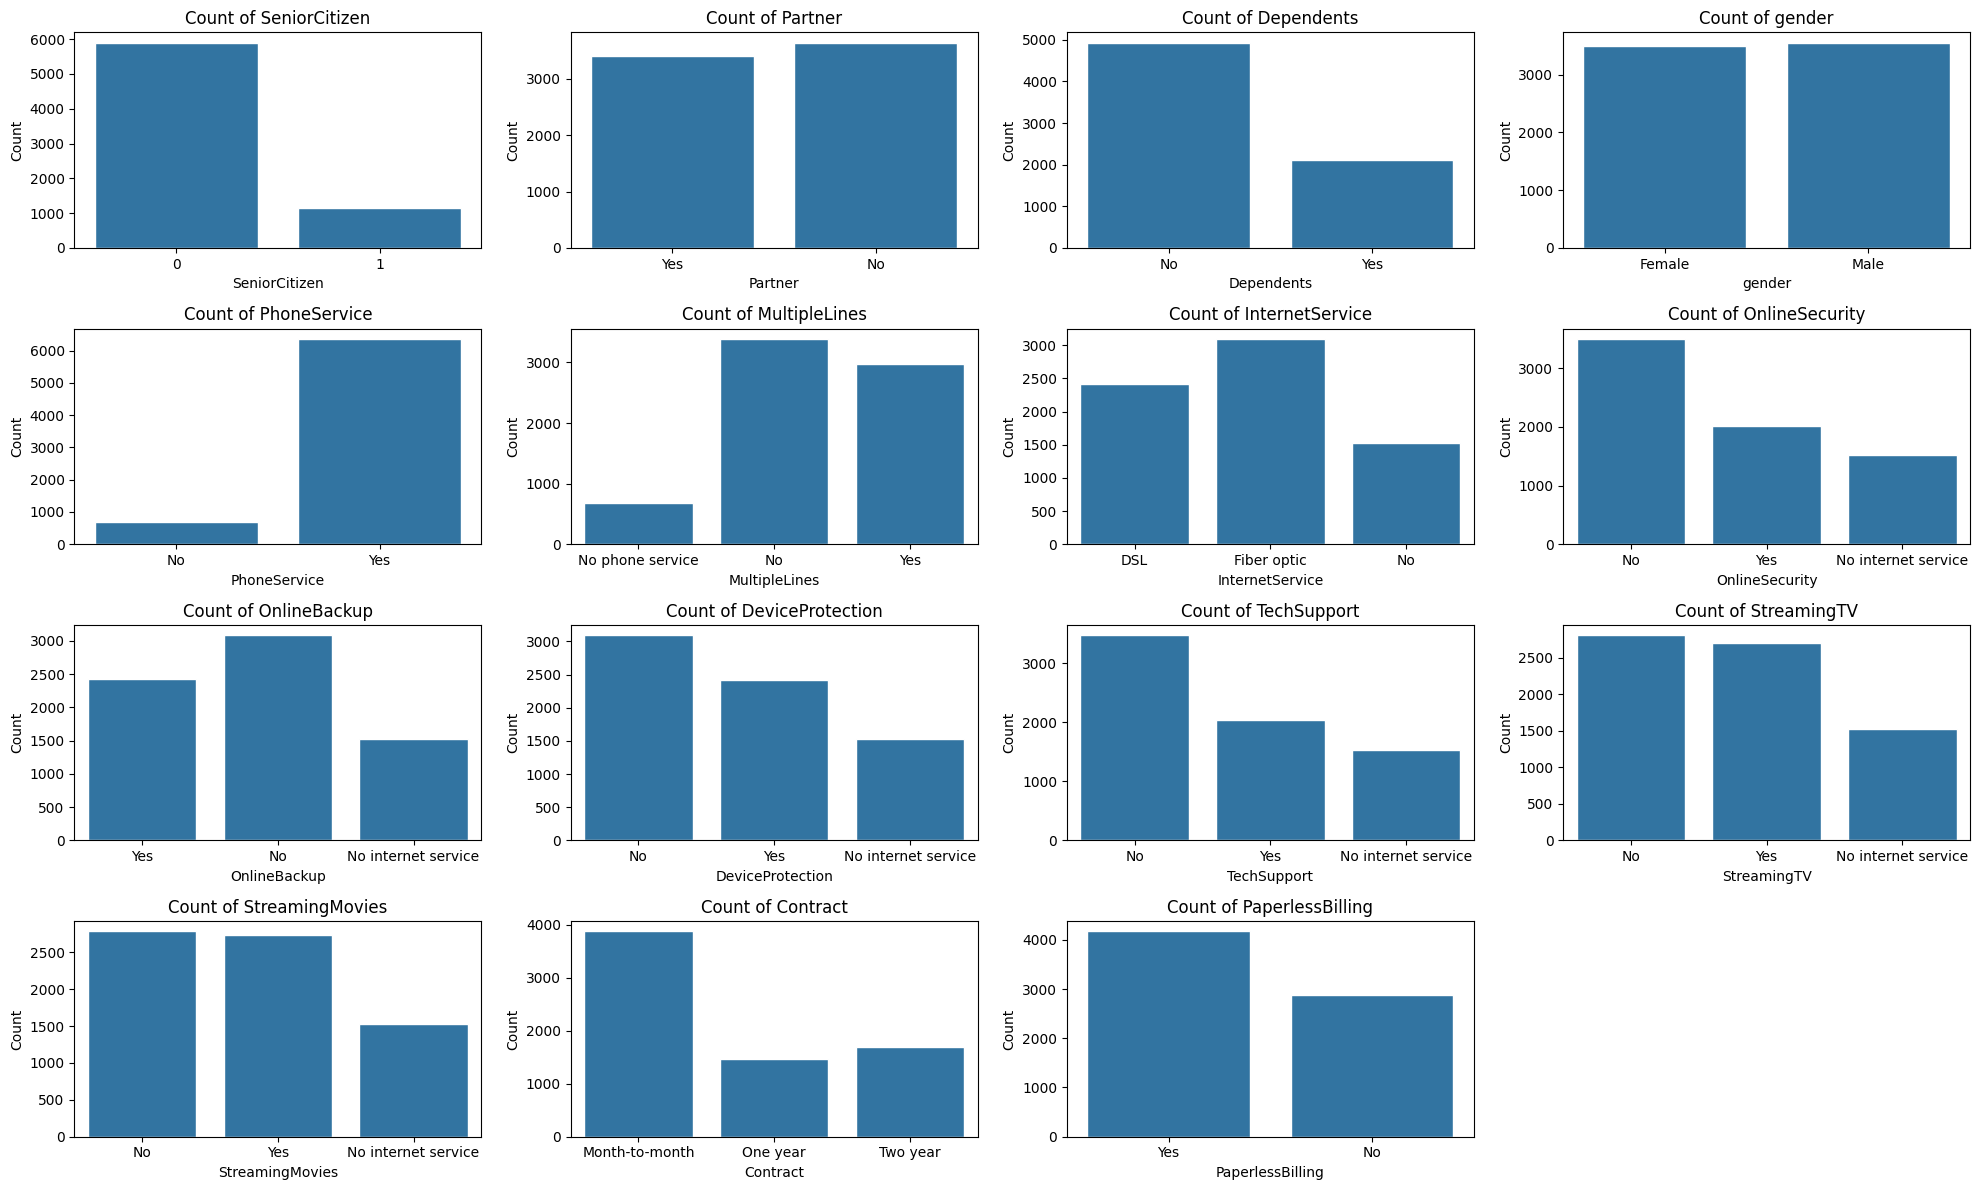

In [15]:
columns_to_plot = ['SeniorCitizen', 'Partner', 'Dependents', 'gender', 'PhoneService',
                   'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
                   ]


# Calcular o número de linhas e colunas baseado no total de variáveis
num_cols = 4  # Definindo 4 colunas
num_rows = (len(columns_to_plot) + num_cols - 1) // num_cols  # Número de linhas necessárias

# Configurando a grade de subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 12))

# Configurando o estilo do grid
sns.set_style("darkgrid", {"grid.color": ".5", "grid.linestyle": ":"})
# Usando a paleta 'Set2'
sns.set_palette("Set2")

# Gerar os gráficos para cada variável
for i, column in enumerate(columns_to_plot):
    ax = axes[i // num_cols, i % num_cols]  # Posicionar na grade
    sns.countplot(x=column, data=df, ax=ax)
    ax.set_title(f'Count of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')

# Remover eixos não usados (caso o número de gráficos não complete a grade)
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes.flatten()[j])

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

# Mostrar o gráfico
plt.show()

Nesta visualização acima, podemos verificar a quantidade de clientes que possuem cada serviço. Essa visualização auxilia na tomada de decisão para qual serviço está mais requisitado ou está caindo em desuso.

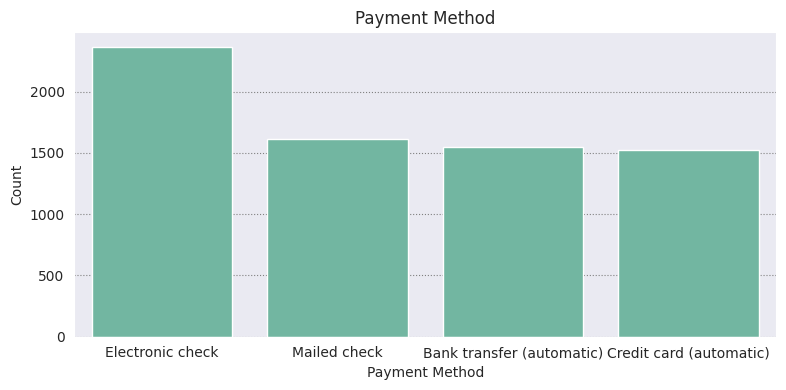

In [16]:
fig, ax = plt.subplots(figsize = (8, 4))
sns.set_style("darkgrid", {"grid.color": ".5", "grid.linestyle": ":"})
# Definindo a paleta de cores
colors = ["#001F3F", "#AAAAAA", "#334C66", "#7D99A8", "#D0D0D0"]
sns.set_palette(sns.color_palette(colors))
count = df['PaymentMethod'].value_counts
sns.countplot(x='PaymentMethod', data = df)
ax.set_xlabel("Payment Method")
ax.set_ylabel("Count")
ax.set_title("Payment Method")
plt.tight_layout();

Este gráfico acima foi plotado fora da visualização com todos os demais gráficos pois possui valores com nomes extensos, então, foi necessário plotar separadamente. Verifica-se então, que o método de pagamento mais utilizado é o cheque eletrônico.

### Análise de variáveis categóricas

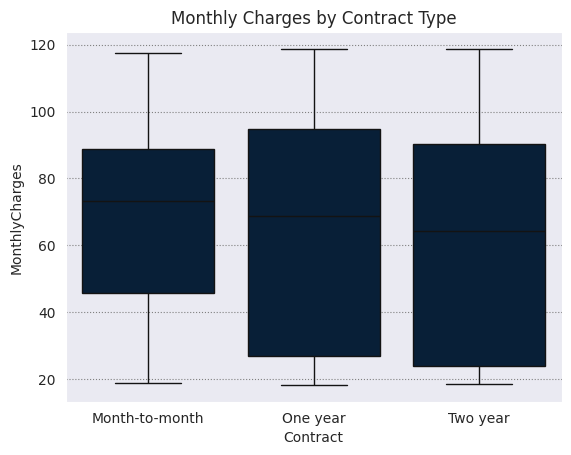

In [17]:
sns.boxplot(x='Contract', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Contract Type')
plt.show()


Aqui, podemos perceber a relação entre o tipo de contrato, e a quantidade de pagamento mensal.

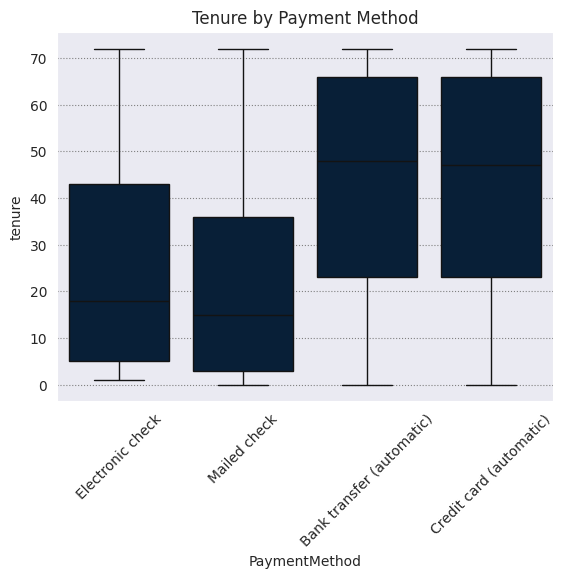

In [18]:
sns.boxplot(x='PaymentMethod', y='tenure', data=df)
plt.title('Tenure by Payment Method')
plt.xticks(rotation=45)
plt.show()

Neste gráfico, podemos perceber o tipo de pagamento relacionado com os meses de contrato. Podemos perceber que a maior permanência de contrato acontece em transferências automáticas e no cartão de crédito (também automático).

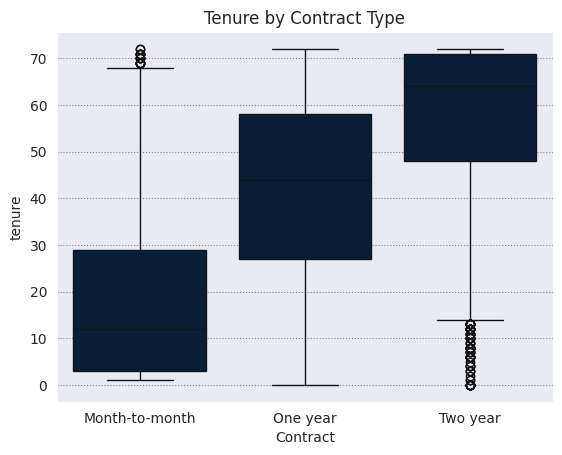

In [19]:
sns.boxplot(x='Contract', y='tenure', data=df)
plt.title('Tenure by Contract Type')
plt.show()

Aqui, podemos perceber que a maior permanência de contrato em meses acontece em contratos de 2 anos.

### Analisando as variáveis com a target Churn

/tmp/ipykernel_3512/1038493651.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='husl')


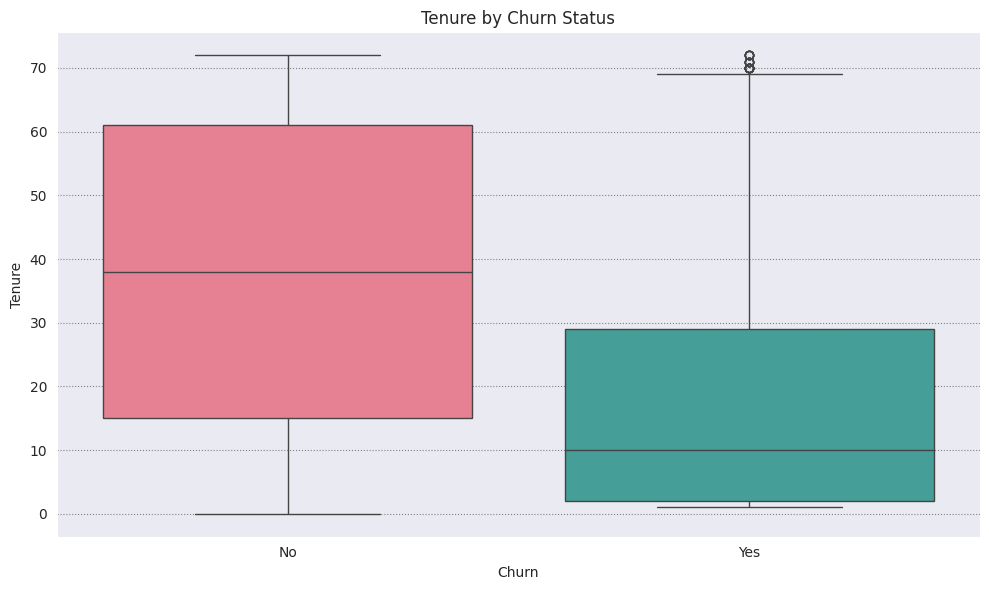

In [20]:
# Definir o estilo dos gráficos
sns.set_style("darkgrid", {"grid.color": ".5", "grid.linestyle": ":"})

# Criar o boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='husl')

# Adicionar título e rótulos
plt.title('Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure')

# Exibir o gráfico
plt.tight_layout()
plt.show()

Neste gráfico, percebe-se que quanto mais meses a pessoa permanece com contrato, maior é a chance de ela não dar Churn.

/tmp/ipykernel_3512/2481920561.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='husl')


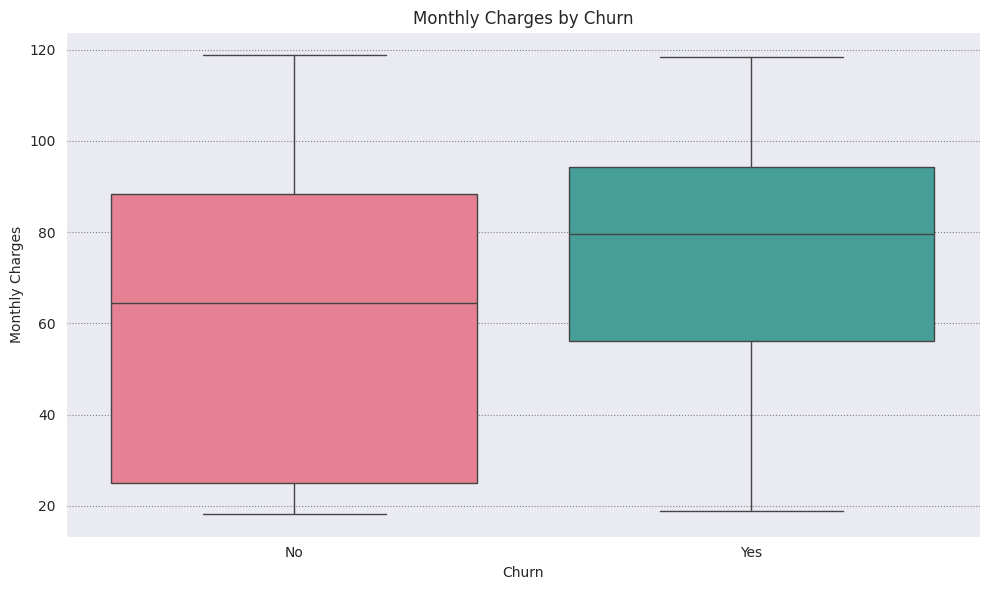

In [21]:
# Definir o estilo dos gráficos
sns.set_style("darkgrid", {"grid.color": ".5", "grid.linestyle": ":"})

# Criar o boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='husl')

# Adicionar título e rótulos
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

# Exibir o gráfico
plt.tight_layout()
plt.show()

Aqui, percebemos que quanto maior a cobrança mensal, maior a chance da pessoa dar Churn.

In [22]:
# Tranformação da coluna TotalCharges para numérica, quando essa transformação é feita, alguns valores não numéricos que existiam nela se transformam em valores nulos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [23]:
# Definindo o valor da média da coluna para preencher os nulos
mean_total_charges = df['TotalCharges'].mean()


In [24]:
# Preencher os valores nulos com a média
df['TotalCharges'].fillna(mean_total_charges, inplace=True)


/tmp/ipykernel_3512/2804322498.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(mean_total_charges, inplace=True)


In [25]:
# Transformando a coluna Senior Citizen em int
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

In [26]:
#Verificação
df['SeniorCitizen'].dtype

dtype('int64')

/tmp/ipykernel_3512/1365223290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='husl')


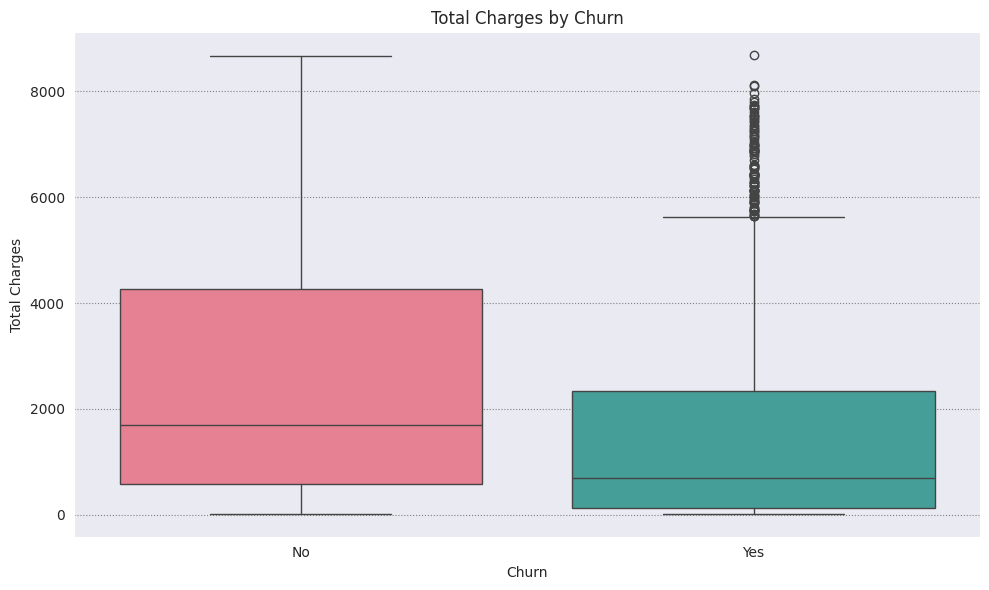

In [27]:
# Definir o estilo dos gráficos
sns.set_style("darkgrid", {"grid.color": ".5", "grid.linestyle": ":"})

# Criar o boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='husl')

# Adicionar título e rótulos
plt.title('Total Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

#Exibir o gráfico
plt.tight_layout()
plt.show()

Aqui, agora podemos analisar que valores maiores para cobranças totais tem uma maior chance para o cliente não abandonar. Isso deve ocorrer devido ao tempo de permanência com a empresa.

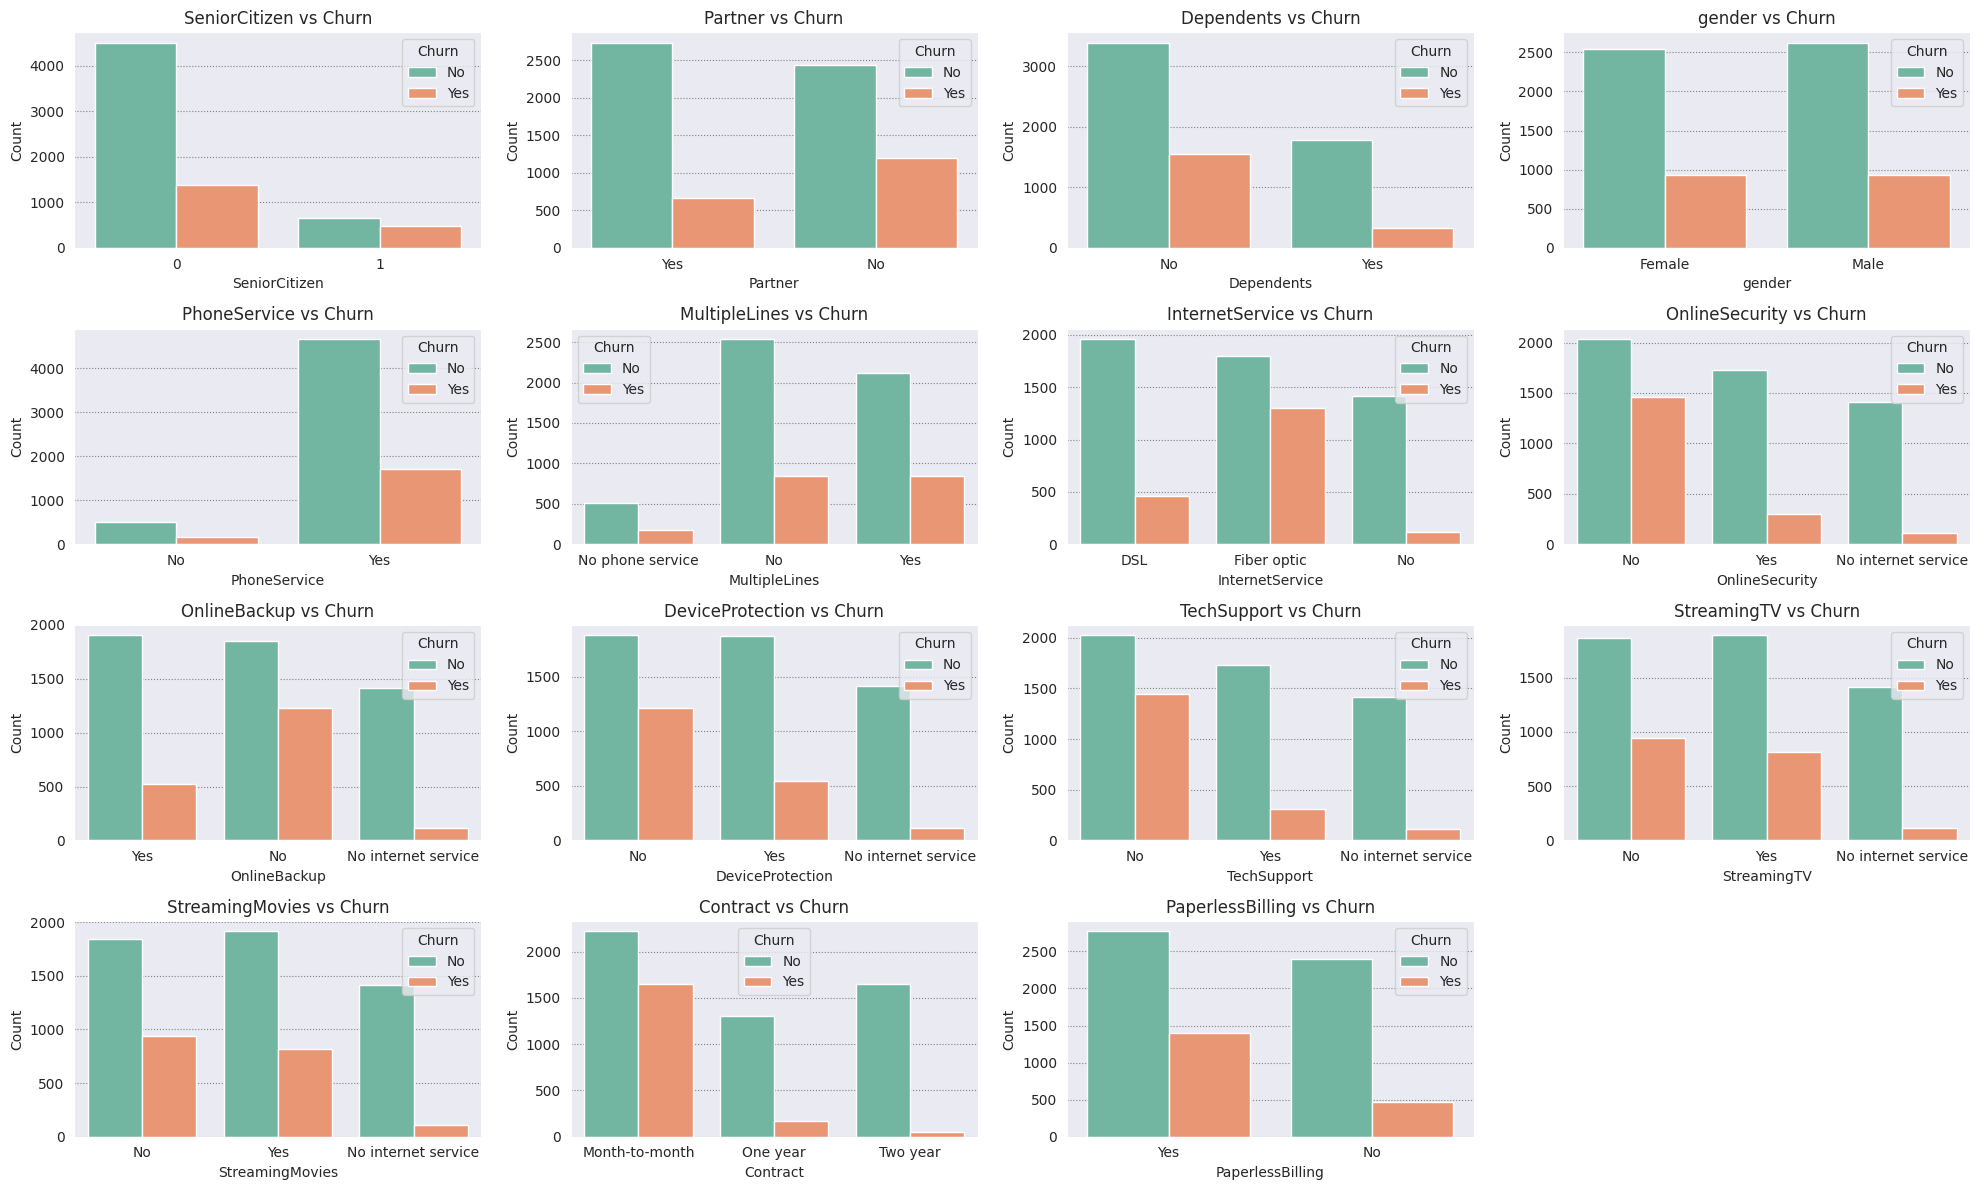

In [28]:
# Definindo as colunas que queremos plotar, incluindo a variável alvo Churn
columns_to_plot = ['SeniorCitizen', 'Partner', 'Dependents', 'gender', 'PhoneService',
                   'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling']

# Calcular o número de linhas e colunas baseado no total de variáveis
num_cols = 4  # Definindo 4 colunas
num_rows = (len(columns_to_plot) + num_cols - 1) // num_cols  # Número de linhas necessárias

# Configurando a grade de subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 12))

# Configurando o estilo do grid
sns.set_style("darkgrid", {"grid.color": ".5", "grid.linestyle": ":"})
# Usando a paleta 'Set2'
sns.set_palette("Set2")

# Gerar os gráficos para cada variável em relação ao Churn
for i, column in enumerate(columns_to_plot):
    ax = axes[i // num_cols, i % num_cols]  # Posicionar na grade
    sns.countplot(x=column, hue='Churn', data=df, ax=ax)  # Usar hue para Churn
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')

# Remover eixos não usados (caso o número de gráficos não complete a grade)
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes.flatten()[j])

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

# Mostrar o gráfico
plt.show()

Nesta visualização, podemos analisar as variáveis relacionadas com a possibilidade ou não de Churn. Alguns serviços como Device Protection, Online Backup, Online Security, Tech Support e Internet Service, quando a pessoa não possui algum deles, a chance de Churn é maior. Além de contratos mensais também possuírem maior chance de Churn.

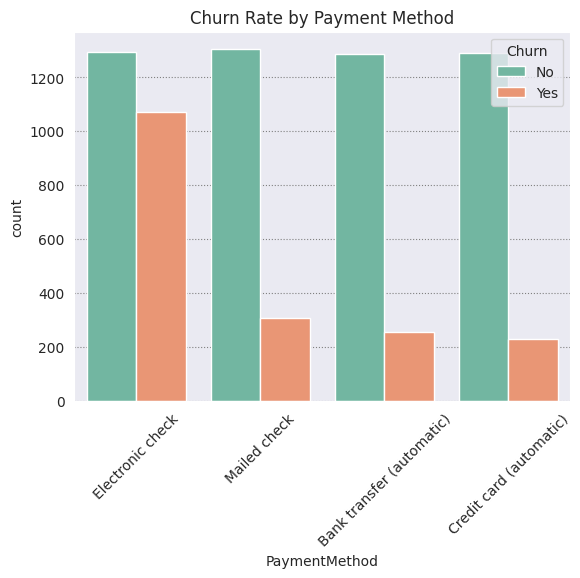

In [29]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn Rate by Payment Method')
plt.xticks(rotation=45)
plt.show()

Neste gráfico, podemos perceber que a maior chance de Churn é para pagamentos em Cheques Eletrônicos, o que causa um problema, pois ao mesmo tempo, é a preferência de método de pagamento dos clientes dessa empresa.

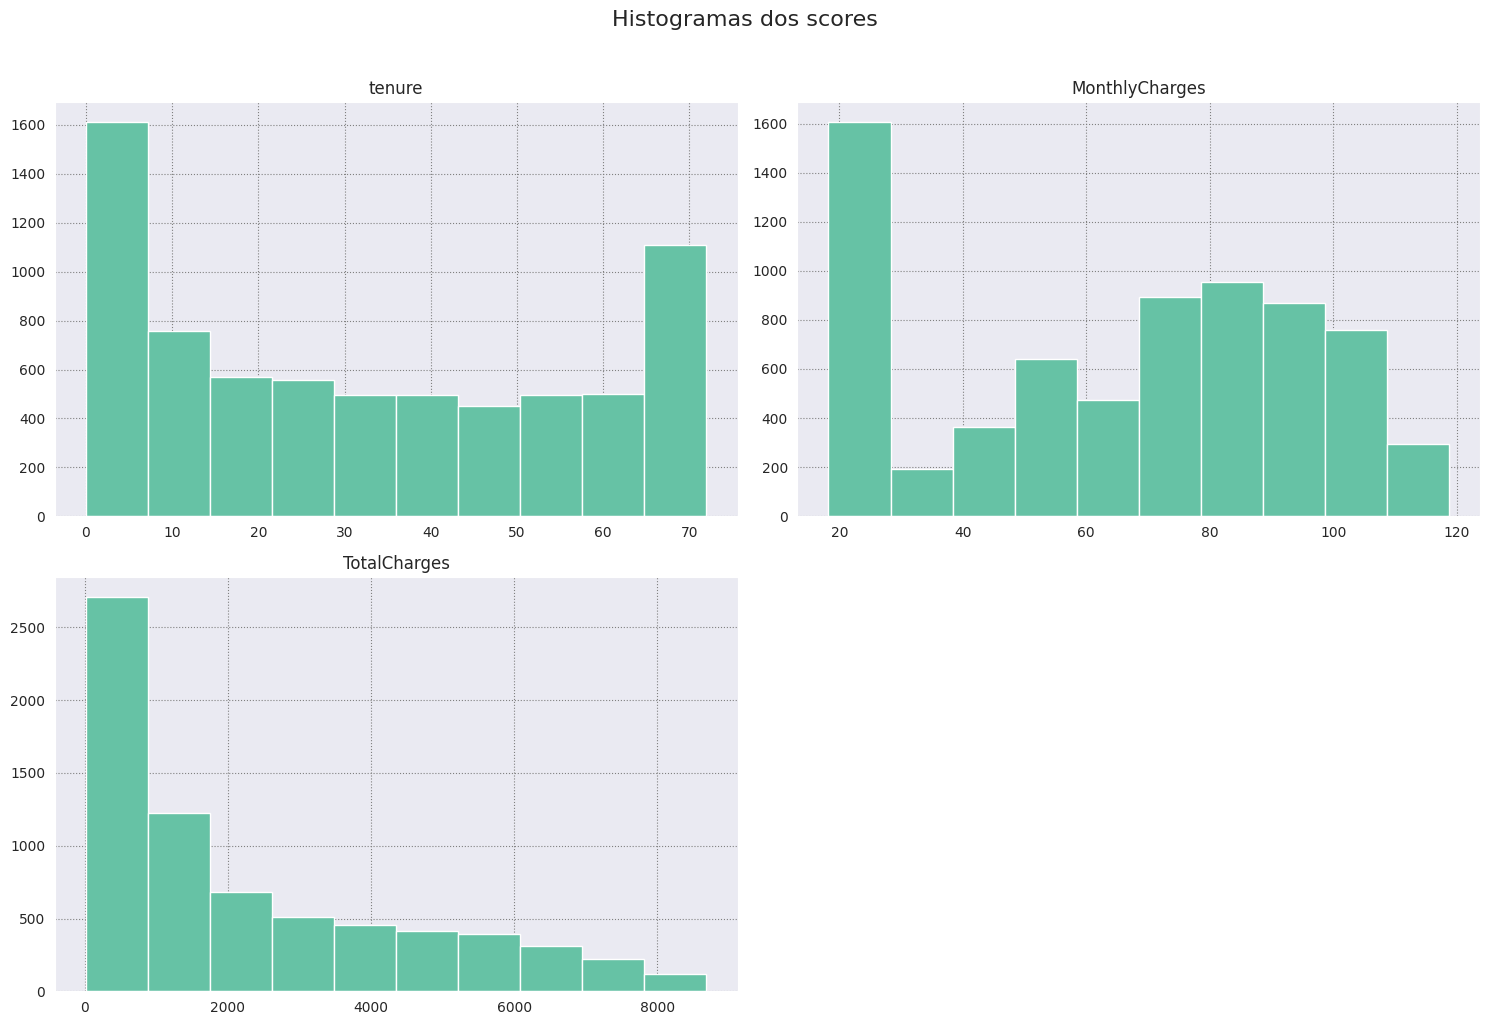

In [30]:
# Gera os histogramas
axarr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(figsize=(15, 10))

# Adiciona um título geral para a figura
plt.gcf().suptitle("Histogramas dos scores", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

Aqui, fiz histogramas das variáveis numéricas para analisar a distribuição dos dados. Verifica-se, portanto, que temos uma distribuição assimétrica para essas variáveis. Isso ajuda na decisão de Normalização ou Padronização dos dados.

## 3. Preparação para o modelo

In [31]:
#Verificação das variáveis object para realizar o Label Encoder
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [32]:
le = LabelEncoder()

# Identificando colunas do tipo object
object_columns = df.select_dtypes(include=['object']).columns.tolist()

# Aplicando o LabelEncoder em cada coluna do tipo object
for column in object_columns:
    df[column] = le.fit_transform(df[column])

# Exibindo as primeiras linhas do DataFrame para verificar as mudanças
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

In [33]:
df[['TotalCharges', 'MonthlyCharges', 'tenure']].describe()

,TotalCharges,MonthlyCharges,tenure
count,7043.000000,7043.000000,7043.000000
mean,2283.300441,64.761692,32.371149
std,2265.000258,30.090047,24.559481
min,18.800000,18.250000,0.000000
25%,402.225000,35.500000,9.000000
50%,1400.550000,70.350000,29.000000
75%,3786.600000,89.850000,55.000000
max,8684.800000,118.750000,72.000000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


## 4. Separação em X e y e treino e teste

In [36]:
x = df.drop('Churn', axis=1)

y = df['Churn']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

## 5. Fazer o escalonamento dos dados (Standard Scaler ou MinMaxScaler)

In [42]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [43]:
# Instanciar o StandardScaler
scaler = StandardScaler()

# Colunas que precisam ser escalonadas
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Ajustar o scaler no conjunto de treino e transformar
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# Usar o scaler ajustado no conjunto de teste
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [44]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2142,0,0,0,1,-0.465683,1,0,0,2,0,2,0,0,2,1,0,3,-0.000474,-0.422099
1623,0,0,0,0,0.885537,1,2,1,0,2,0,0,2,2,2,1,0,1.074754,1.255366
6074,1,0,1,0,-1.284605,0,1,0,0,0,0,0,0,0,0,1,2,-1.376499,-1.002985
1362,1,0,0,0,-1.161766,1,0,1,0,0,0,0,0,0,0,1,2,0.177346,-0.908113
6754,1,0,0,1,-1.325551,1,2,0,2,2,0,2,0,0,2,1,0,-0.098524,-0.003468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,1,0,1,0,-1.284605,1,0,1,2,0,0,0,2,2,0,1,2,1.001632,-0.971339
5191,0,0,1,1,-0.383791,1,2,0,2,2,2,2,2,2,2,1,1,0.872006,-0.041063
5226,1,0,1,1,-0.834198,1,0,2,1,1,1,1,1,1,0,1,2,-1.452945,-0.877993
5390,1,1,0,0,-0.834198,1,2,1,0,0,2,0,2,2,0,1,2,1.149538,-0.482538


## 6. Escolha e definição dos modelos

In [45]:
rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)


## 7. Treinamento do Modelo

In [46]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 8. Previsões e Avaliações